### Explore Data matches

In [24]:
import psycopg2
import os
from pathlib import Path
from dotenv import load_dotenv
import logging
import pandas as pd
import numpy as np
from psycopg2 import sql
from psycopg2.extras import execute_values
import matplotlib.pyplot as plt

load_dotenv()

True

### Connect database

In [3]:
db_host = os.getenv("DB_HOST", "localhost")

conn = psycopg2.connect(
    host="localhost",
    port=os.getenv("DB_PORT", "5432"),
    dbname=os.getenv("POSTGRES_DB", "db_etl"),
    user=os.getenv("POSTGRES_USER", "etl_user"),
    password=os.getenv("POSTGRES_PASSWORD", "etl_pass"),
)


### CATCH MATCHES

In [7]:
cursor = conn.cursor()
sql_query = sql.SQL("""SELECT
    *
FROM
    etl.fact_matches
""")
cursor.execute(sql_query)
records = cursor.fetchall()
df = pd.DataFrame(records, columns=[desc[0] for desc in cursor.description])

print(df.head(10))


   match_id  date_id  season_id  division_id  home_team_id  away_team_id  \
0     42829        1          1            1            65            83   
1     42830        1          1            1            66            82   
2     42831        2          1            1            67            84   
3     42832        2          1            1            68            78   
4     42833        2          1            1            69            79   
5     42834        2          1            1            70            77   
6     42835        2          1            1            71            76   
7     42836        3          1            1            72            81   
8     42837        3          1            1            73            75   
9     42838        3          1            1            74            80   

   result_match  result_ht  home_score  away_score  ...  home_corners  \
0             2        1.0           0           1  ...           2.0   
1             1  

### Info of the data

In [13]:
print(df.shape[0])

10778


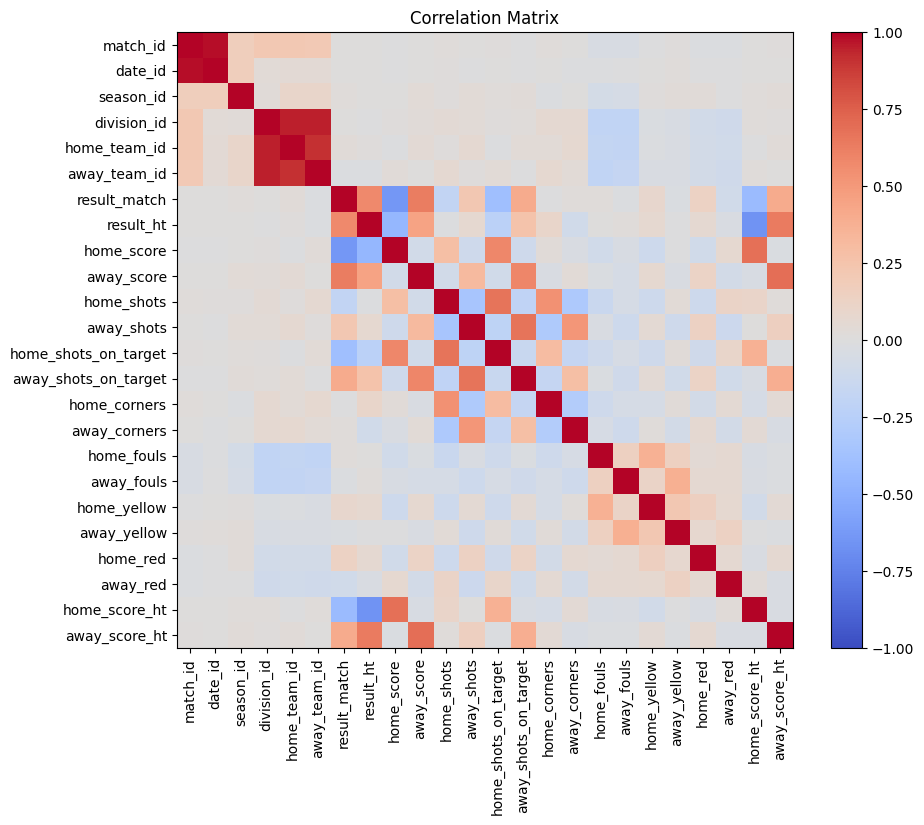

In [14]:
corr = df.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title('Correlation Matrix')
plt.show()

## Grafics and outliers

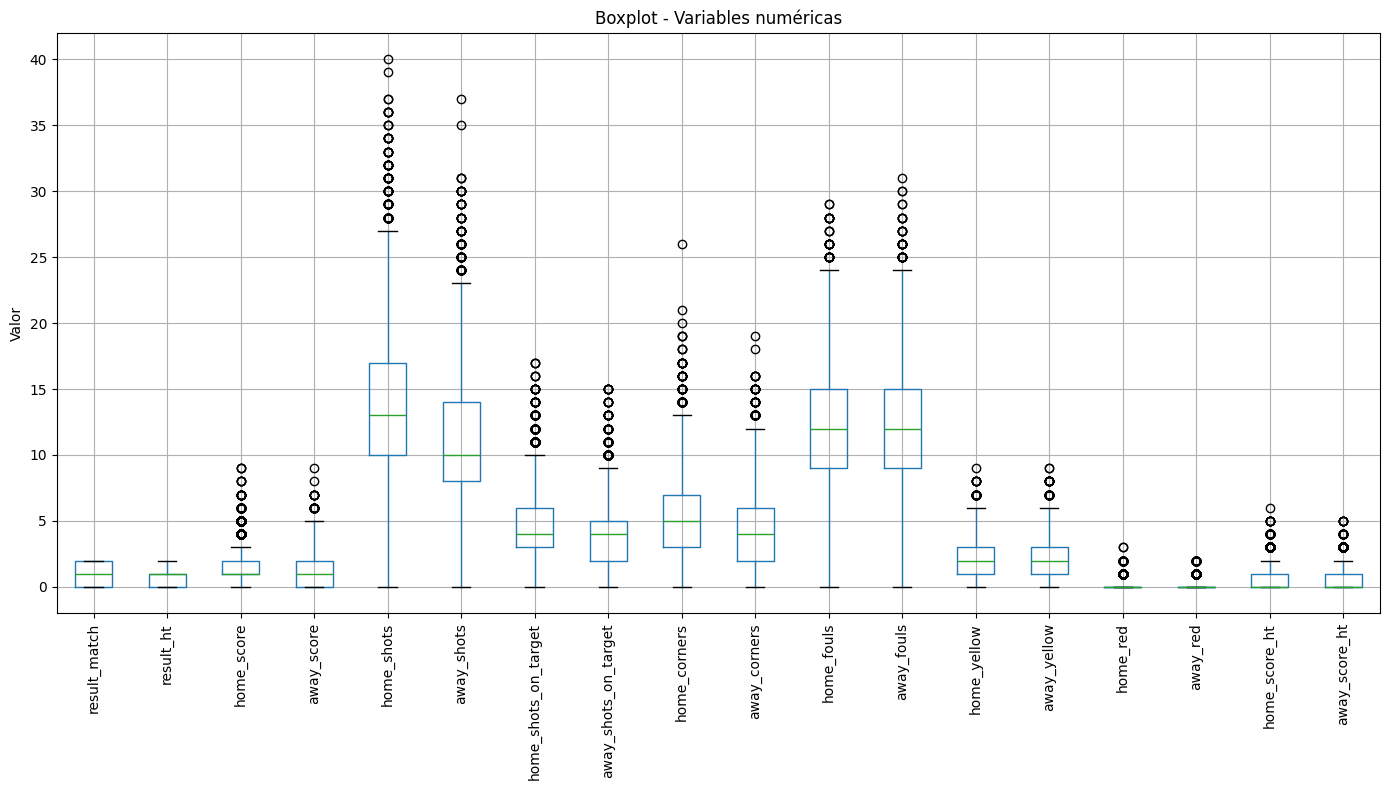

In [20]:
df_without_id = df.drop(columns=["match_id", "season_id", "division_id", "home_team_id", "away_team_id", "date_id"])
numeric_cols = df_without_id.select_dtypes(include='number')

fig, ax = plt.subplots(figsize=(14, 8))
numeric_cols.boxplot(ax=ax, vert=True, rot=90)
ax.set_title('Boxplot - Variables numéricas')
ax.set_ylabel('Valor')
plt.tight_layout()
plt.show()

Desviación estándar - home_shots: 5.237257936783967
Mean - home_shots: 13.474993040734898


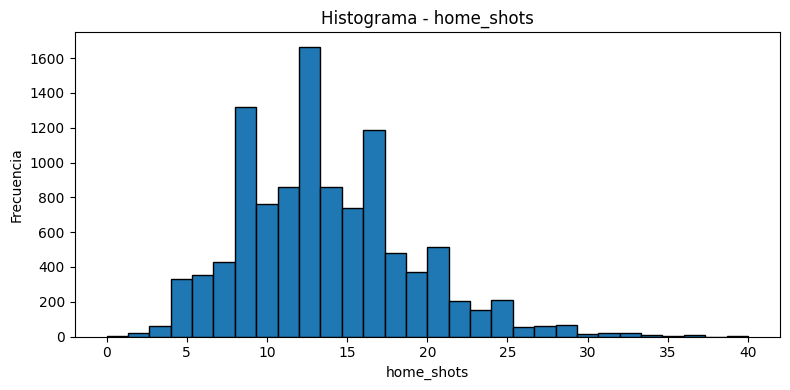

Desviación estándar - away_shots: 4.688615218330395
Mean - away_shots: 11.013547369397791


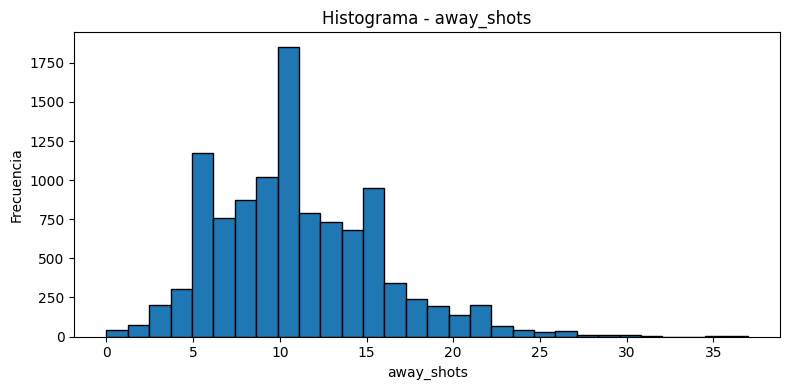

Desviación estándar - home_fouls: 3.937713745549552
Mean - home_fouls: 12.08972812471003


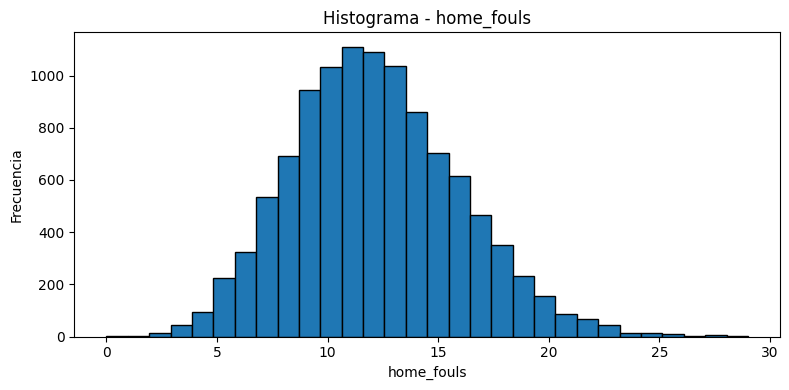

Desviación estándar - away_fouls: 3.9969181173586614
Mean - away_fouls: 12.242275215737218


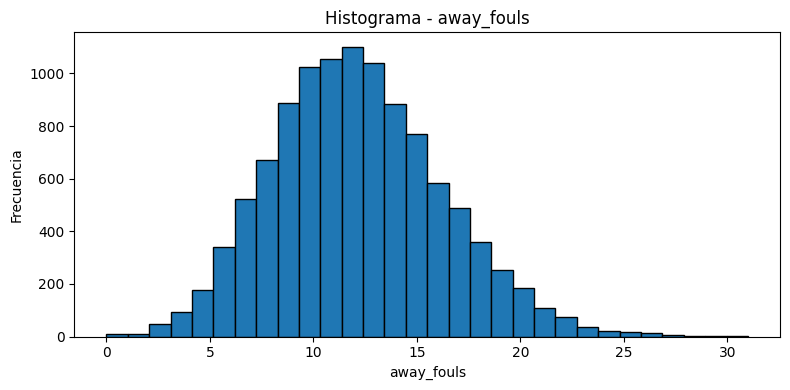

In [36]:
columns_to_check = ["home_shots", "away_shots","home_fouls", "away_fouls"]
for col in columns_to_check:
    print("=" * 40)
    print(f'Desviación estándar - {col}: {numeric_cols[col].std()}')
    print(f'Mean - {col}: {numeric_cols[col].mean()}')
    plt.figure(figsize=(8, 4))
    plt.hist(numeric_cols[col], bins=30, edgecolor='k')
    plt.title(f'Histograma - {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

In [39]:
print(numeric_cols[numeric_cols["home_shots"] > 30].shape[0])
print(numeric_cols[numeric_cols["away_shots"] > 25].shape[0])
print(numeric_cols[numeric_cols["home_fouls"] > 23].shape[0])
print(numeric_cols[numeric_cols["away_fouls"] > 23].shape[0])

58
62
49
64


Desviación estándar - home_corners: 2.9304955451606607
Mean - home_corners: 5.403637375893106


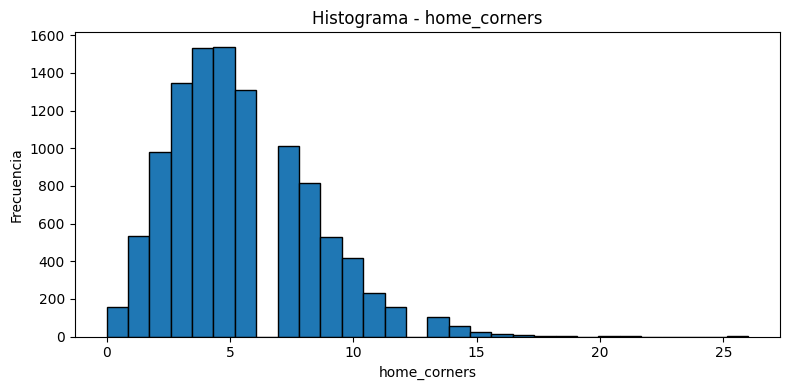

Desviación estándar - away_corners: 2.616160014232174
Mean - away_corners: 4.381182147165259


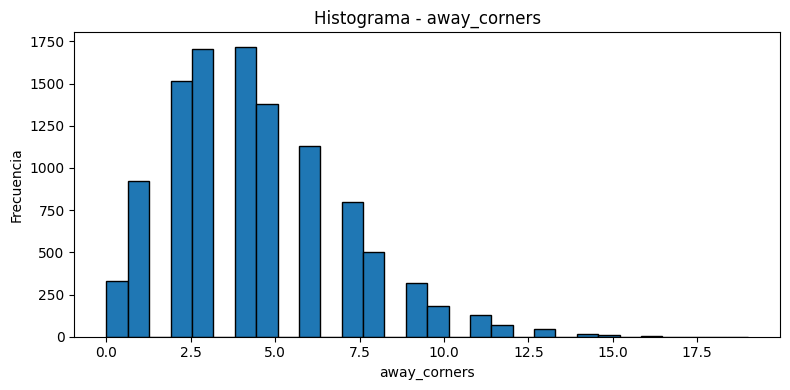

In [40]:
columns_to_check = ["home_corners", "away_corners"]
for col in columns_to_check:
    print("=" * 40)
    print(f'Desviación estándar - {col}: {numeric_cols[col].std()}')
    print(f'Mean - {col}: {numeric_cols[col].mean()}')
    plt.figure(figsize=(8, 4))
    plt.hist(numeric_cols[col], bins=30, edgecolor='k')
    plt.title(f'Histograma - {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

In [41]:
print(numeric_cols[numeric_cols["home_corners"] > 13].shape[0])
print(numeric_cols[numeric_cols["away_corners"] > 12].shape[0])

110
80
